## Co mój komputer paczy, czyli czy sztuczna inteligencja pozna się na ptakach

Niektóre rzeczy, które dla nas wydają się być zupełnie oczywiste, przez wiele dziesięcioleci wydawały się kompletnie niewykonalne dla komputerów. Jak to zręcznie ujął Randal Munroe, autor komiksu XKCD
<img style="display: block; margin: 20px auto; height: 300px;" src="tasks_2x.png">
Credit: Tasks by Randal Munroe https://xkcd.com/1425/

Komiks ten powstał w 2014 roku, dosłownie w przededniu rewolucji, jaką Deep Learning spowodował w komputerowej analizie obrazów. Po mniej więcej 60 latach prób i wielu falstartach problem ten udało się rozwiązać, a teraz każdy może nauczyć komputer bardzo skutecznie rozpoznawać dowolne obiekty na zdjęciach.

Wszelkie algorytmy Sztucznej Inteligencji (AI) albo Uczenia Maszynowego (ML) polegają na tym, żeby zamiast zapisać szczegółowy algorytm rozwiązania danego problemu, maszyna potrafiła sama nauczyć się to robić na podstawie odpowiednio dużej ilości przykładów.

Oczywiście maszyna nie zrobi niczego "sama", my musimy:
1. przygotować odpowiednią dla danego problemu sieć neuronową,
2. zebrać dane, czyli przykłady prawidłowego rozwiązania problemu,
3. wybrać sposób oceny, czy problem został rozwiązany poprawnie,
4. sprawdzić, czy komputer faktycznie nauczył się tego na czym nam zależy https://www.gwern.net/Tanks .

### Dane, czyli przykłady

Chcemy nauczyć komputer rozpoznawać co widzi na zdjęciu, więc potrzebujemy dużej ilości zdjęć. Moglibyśmy wyjść na dwór z aparatem i pstrykać, ale zrobienie kilkuset zdjęć każdego z interesujących nas obiektów zajęłoby nam sporo czasu. W rzeczywistości zebranie odpowiednio dużej ilości danych treningowych jest dużym wyzwaniem dla wdrażania systemów sztucznej inteligencji. Na potrzeby tego ćwiczenia możemy sprytnie  obejść ten problem posiłkując się wyszukiwarkami obrazów.

Jeśli na Bing Images wpiszemy hasło `orzeł ptak`, to dostaniemy setki różnorodnych zdjęć bocianów, które jak ulał nadadzą się do trenowania naszego algorytmu:

<img src="orzel-1.jpg" /><img src="orzel-2.jpg" /><img src="orzel-3.jpg" /><img src="orzel-4.jpg" />

Podobnie możemy zrobić z kilkoma innymi hasłami, na przykład: `bocian`, `kura`, `kogut`

Możemy dość łatwo pobrać wszystkie te zdjęcia na nasz komputer. W tym celu powinniśmy przewienać na sam dół, uruchomić narzędzia developerskie i wkleić w nie taki kawałek kodu w JavaScript:
    
```js
console.save = function (data, filename) {
    if (!data) {
        console.error('Console.save: No data')
        return;
    }

    if (!filename) filename = 'story.json'

    if (typeof data === "object") {
        data = JSON.stringify(data, undefined, 4)
    }

    var blob = new Blob([data], {
            type: 'text/json'
        }),
        e = document.createEvent('MouseEvents'),
        a = document.createElement('a')

    a.download = filename
    a.href = window.URL.createObjectURL(blob)
    a.dataset.downloadurl = ['text/json', a.download, a.href].join(':')
    e.initMouseEvent('click', true, false, window, 0, 0, 0, 0, 0, false, false, false, false, 0, null)
    a.dispatchEvent(e)
}

results = "";
for(var img of document.getElementsByClassName('iusc'))
  results +=  img.getAttribute('m')+"\n";
console.save(results, document.getElementById('sb_form_q').value+'.json');
```

To zapisze na naszym dysku plik JSON nazwany tak jak nasze wyszukiwanie i zawierający adresy wszystkich obrazków, które były wynikami naszego wyszukiwania.

Następnie ściągamy wszystkie te zdjęcia:

In [2]:
!mkdir -p orzel && cd orzel && jq -r .murl < "../orzeł ptak.json" | parallel curl -s -O
!mkdir -p bocian && cd bocian && jq -r .murl < "../bocian.json" | parallel curl -s -O
!mkdir -p kura && cd kura && jq -r .murl < "../kura.json" | parallel curl -s -O
!mkdir -p kogut && cd kogut && jq -r .murl < "../kogut.json" | parallel curl -s -O

Jeśli mamy już zdjęcia, to możemy przygotować je do procesu uczenia.

In [3]:
from fastai.vision.all import *

In [4]:
# find all the image files
all_images = []
for dirname in ["orzel", "bocian", "kura", "kogut"]:
    all_images += get_image_files(dirname)
# delete all the files that we could not open
verify_images(all_images).map(os.unlink)
# get the new list, without the deleted photos:
all_images = []
for dirname in ["orzel", "bocian", "kura", "kogut"]:
    all_images += get_image_files(dirname)

In [5]:
len(all_images)

2092

In [6]:
# get one image
fname = all_images[0]; fname

Path('orzel/orły-orzeł-przedni-640x468.jpg')

Nazwa katalogu jest jednocześnie naszą etykietą. Jeśli razem z każdym zdjęciem podamy komputerowi jedną z etykiet, to będziemy mogli nauczyć go nazywać podobne zdjęcia. Przetestujmy to na jednej nazwie pliku:

In [7]:
# extract the folder name (this will be our label)
fname.parent.name

'orzel'

Teraz stworzymy `DataLoader`, czyli obiekt, który zbiera w całość wszystkie obrazki oraz ich poprawne etykiety.
Dodatkowo ustawiamy `valid_pct` na 20%. Podobnie jak w przypadku studentów, komputer najchętniej zapamiętał by dokładnie każde
z przedstawionych mu zdjęć. Wtedy zamiast uczyć się rozpoznawać cechy charakterystyczne każdego z ptaków, może wkuć na pamięć wszystkie etykiety. A komputer jest dużo lepszy w te klocki niż studenci... ;)

Żeby sprawdzić czy algorytm nie "oszukuje" możemy losowo wybrać 20% naszych zdjęć i schować je podczas uczenia, abyśmy na koniec mogli zrobić mu test i sprawdzić czy nie oszukiwał.

In [8]:
def what_bird(fname): return fname.parent.name
dls = ImageDataLoaders.from_path_func(
    '.', all_images, valid_pct=0.2, seed=42,
    label_func=what_bird, item_tfms=Resize(224))

A teraz nauczymy model ResNet34, który dobrze sprawdza się w problemach rozpoznawania obrazów odróżniać kurę od orła i bociana:

In [9]:
learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.225498,0.592688,0.179426,00:19


epoch,train_loss,valid_loss,error_rate,time
0,0.645568,0.541884,0.196172,00:18
1,0.456752,0.498632,0.165072,00:18
2,0.306426,0.477164,0.167464,00:18


W tym wypadku cały proces trwa niecałe dwie minuty, ale jeśli mielibyśmy setki milionów zdjęć, to uczenie wymagałoby wielu komputerów i trwało nawet kilka dni.

`error_rate` to ilość błędów, które popełniła sieć neuronowa na naszym zbiorze walidacyjnym. W tym wypadku jest to około 16%. Wydaje się być całkiem sporo, więc spróbujmy sprawdzić o co tu może chodzić.

Najpierw wygenerujmy tzw. Confusion Matrix, czyli zestawienie pokazujące ile zdjęć ze zbioru walidacyjnego kur zostało sklasyfikowanych jako kury, a ile sieć uważała za `koguta`, `orła` lub `bociana`.

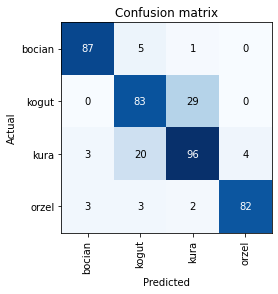

In [10]:
interp = ClassificationInterpretation.from_learner(learn, ds_idx=1)
interp.plot_confusion_matrix()

Widać, że większość odpowiedzi sieci neuronowej jest poprawna (ciemne kwadraty na przekątnej), ale rozróżnienie kury od koguta nie jest wcale takie proste.

Zarówno całościowy `error_rate`, jak i Confusion Matrix pozwalają nam odkryć jedynie statystyczne (iloścowe) parametry naszego algorytmu. Możemy podejśc do sprawy od strony jakościowej, czyli ustalić dla jakich konkretnie obrazów nasza sieć myliła się najbardziej:

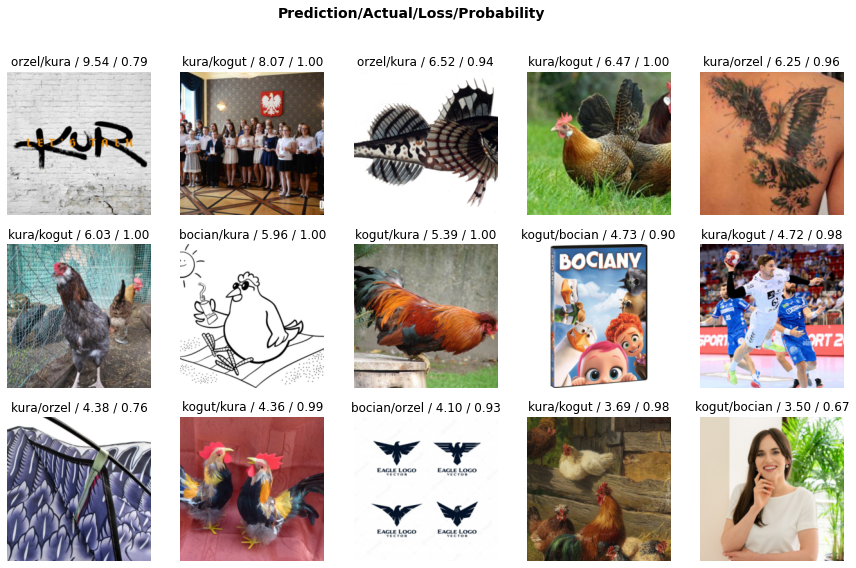

In [11]:
interp.plot_top_losses(15, nrows=3)

Bliższe przyjżenie się tym obrazkom pokazuje, że głównym winowacją jesteśmy my, a nie nasza sieć. Wiele z tych zdjęć albo nie przedstawia żadnego z interesujących nas ptaków (ale zabawkę, rybę? albo okładkę książki) albo przedstawia te ptaki w nietypowy sposób (czarno-białe rysunki) albo jest po prostu mylnie sklasyfikowana.

Ponieważ algorytmy wyszukiwarek wciąż w dużej mierze opierają się na analizie tekstu, który otaczał  obrazek, to wyszukiwarki potrafią pokazywać obrazki zupełnie nie związane z hasłem wyszukiwania.